In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sho_kernel_tau(tau, sigma, omega, Q):
    """
    SHO kernel k(tau), where tau = |t_i - t_j|.

    Parameters
    ----------
    tau : float or array
        Time lag(s).
    sigma : float
        Kernel amplitude.
    omega : float
        Angular frequency, omega = 2*pi / period.
    Q : float
        Quality factor.

    Returns
    -------
    k : float or array
        Covariance value(s).
    """
    tau = np.asarray(tau, dtype=float)
    tau_abs = np.abs(tau)

    prefactor = sigma**2 * np.exp(-omega * tau_abs / (2.0 * Q))

    # Handle Q = 1/2 approximately
    if np.isclose(Q, 0.5):
        bracket = 1.0 + omega * tau_abs

    elif Q < 0.5:
        f = np.sqrt(1.0 - 4.0 * Q**2)
        arg = f * omega * tau_abs / (2.0 * Q)
        bracket = np.cosh(arg) + np.sinh(arg) / f

    else:
        g = np.sqrt(4.0 * Q**2 - 1.0)
        arg = g * omega * tau_abs / (2.0 * Q)
        bracket = np.cos(arg) + np.sin(arg) / g

    return prefactor * bracket


def plot_sho_kernel(
    sigma,
    omega,
    Q,
    tau_max=None,
    n_tau=1000,
    period_units=True,
):
    """
    Plot SHO kernel as a function of lag tau.

    Parameters
    ----------
    sigma : float
        Kernel amplitude.
    omega : float
        Angular frequency.
    Q : float
        Quality factor.
    tau_max : float or None
        Maximum lag to plot. If None, uses 5 periods.
    n_tau : int
        Number of lag samples.
    period_units : bool
        If True, x-axis is tau / period. Otherwise x-axis is tau.
    """
    period = 2.0 * np.pi / omega

    if tau_max is None:
        tau_max = 5.0 * period

    tau = np.linspace(0.0, tau_max, n_tau)
    k = sho_kernel_tau(tau, sigma=sigma, omega=omega, Q=Q)

    x = tau / period if period_units else tau
    xlabel = r"$\tau / P$" if period_units else r"$\tau$"

    plt.figure()
    plt.plot(x, k)
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel(xlabel)
    plt.ylabel(r"$k(\tau)$")
    plt.title(fr"SHO kernel: $\sigma={sigma}$, $\omega={omega:.3g}$, $Q={Q}$")
    plt.show()

    return tau, k

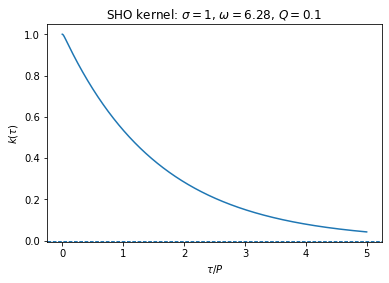

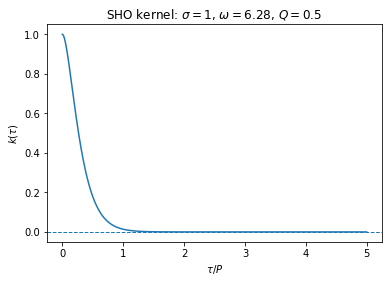

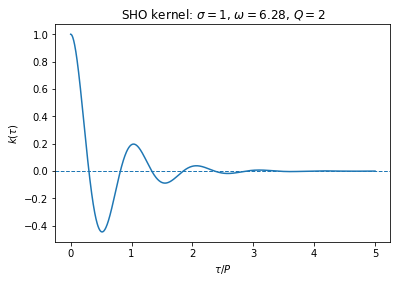

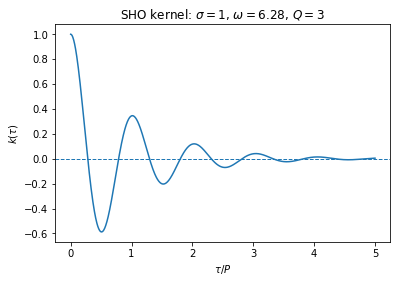

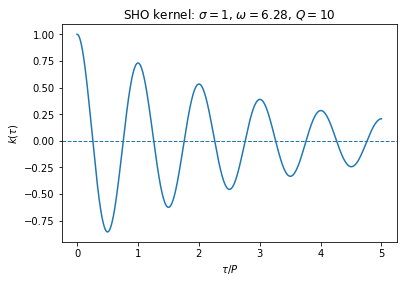

In [12]:
sigma = 1.0
period = 2.0
omega = 2.0 * np.pi / period
Q = 10.0

#Q is decay constant
#sigma is amplitude constant
#period is period
tau, k = plot_sho_kernel(sigma=1, omega=2.0*np.pi/1, Q=0.1)
tau, k = plot_sho_kernel(sigma=1, omega=2.0*np.pi/1, Q=0.5)
tau, k = plot_sho_kernel(sigma=1, omega=2.0*np.pi/1, Q=2)
tau, k = plot_sho_kernel(sigma=1, omega=2.0*np.pi/1, Q=3)
tau, k = plot_sho_kernel(sigma=1, omega=2.0*np.pi/1, Q=10)

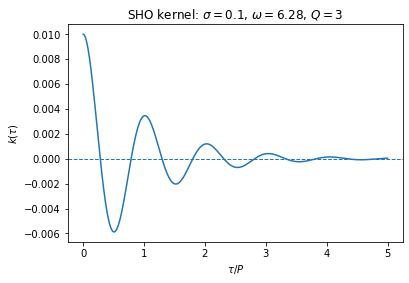

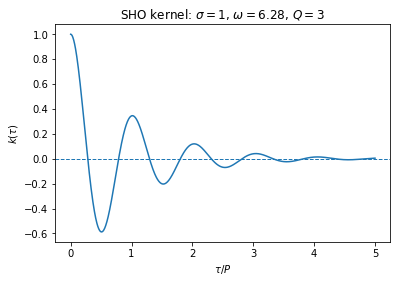

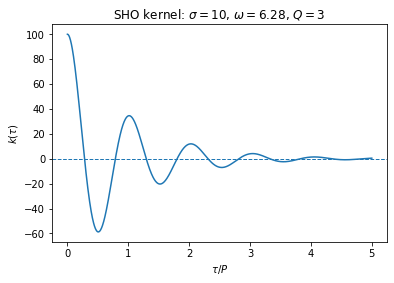

In [14]:

tau, k = plot_sho_kernel(sigma=0.1, omega=2.0*np.pi/1, Q=3)
tau, k = plot_sho_kernel(sigma=1, omega=2.0*np.pi/1, Q=3)
tau, k = plot_sho_kernel(sigma=10, omega=2.0*np.pi/1, Q=3)
